In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

from dpks import QuantMatrix

In [2]:

def preprocess_design_matrix(design_matrix, col):

    design_matrix['group'] = np.where(
        design_matrix[col] > design_matrix[col].mean(), 2, 1
    )

    design_matrix['sample'] = design_matrix['injection']

    return design_matrix

In [3]:
def preprocess_data(raw_data, design_matrix):

    quant_matrix = QuantMatrix(
        quantification_file=raw_data[['Protein'] + [sample for sample in design_matrix['sample'].values]].copy(),
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_data/2023-04-24-UP000005640.fas"
    )

    quant_data = quant_matrix.to_df()
    
    quant_data = quant_data[~((quant_data["ProteinLabel"].str.startswith("HV")) | (quant_data["ProteinLabel"].str.startswith("LV")) | quant_data["ProteinLabel"].str.startswith("KV"))]
    quant_data = quant_data[~quant_data["ProteinLabel"].str.startswith("IG")]
    quant_data = quant_data[~((quant_data["ProteinLabel"] == "HBA_HUMAN") | (quant_data["ProteinLabel"] == "HBB_HUMAN") | (quant_data["ProteinLabel"] == "HBD_HUMAN") | (quant_data["ProteinLabel"] == "HEMO_HUMAN"))]

    quant_matrix = QuantMatrix(
        quantification_file=quant_data,
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_data/2023-04-24-UP000005640.fas"
    )

    return quant_matrix     


# Model Training

In [4]:
ms_data = pd.read_csv(
    "../0_data/proteins_train_filtered.tsv"
    , sep="\t"
)

In [5]:
design_matrix_otrain = pd.read_csv(
    "organ_dysfunction_design_matrix.tsv",
    sep="\t"
)

In [6]:
rate_col = "Coag Rate"

In [7]:
design_matrix_otrain[rate_col].mean()

0.19976617647058825

In [8]:
design_matrix_train = preprocess_design_matrix(design_matrix_otrain.copy(), rate_col)

<Axes: >

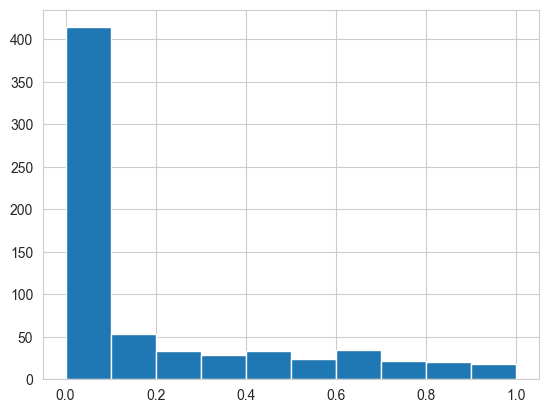

In [9]:
design_matrix_train[rate_col].hist(bins=10)

In [10]:
design_matrix_train['group'].value_counts()

group
1    467
2    213
Name: count, dtype: int64

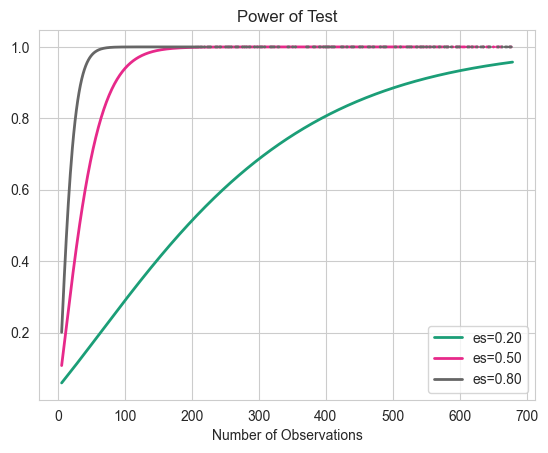

In [11]:
from statsmodels.stats.power import TTestIndPower
import matplotlib.pyplot as plt

# parameters for power analysis
effect_sizes = np.array([0.2, 0.5, 0.8])
sample_sizes = np.array(range(5, design_matrix_train.shape[0]))


analysis = TTestIndPower()

analysis.plot_power(dep_var='nobs', nobs=sample_sizes, effect_size=effect_sizes)
plt.show()

In [12]:
quant_matrix_train = preprocess_data(ms_data, design_matrix=design_matrix_train)

In [13]:
quant_matrix_train = quant_matrix_train.compare(
    method="linregress",
    comparisons=(2,1),
    min_samples_per_group=2,
    level="protein",
    multiple_testing_correction_method="fdr_tsbh"
)

In [14]:
#quant_matrix_train.write("de_results/resp_de_proteins.tsv")

In [15]:
quant_matrix_de = quant_matrix_train.to_df()

<Axes: xlabel='Log2FoldChange2-1', ylabel='-Log10CorrectedPValue2-1'>

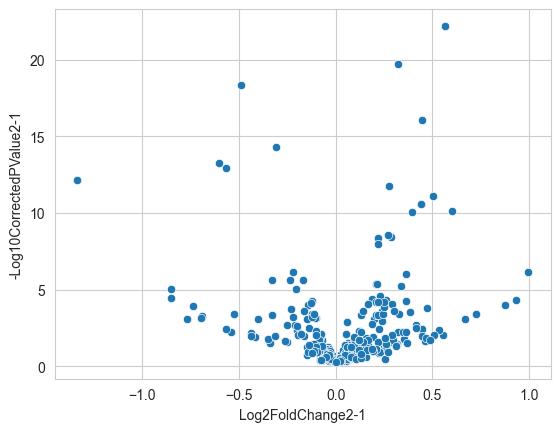

In [16]:
sns.scatterplot(
    data=quant_matrix_de,
    x="Log2FoldChange2-1",
    y="-Log10CorrectedPValue2-1"
)

In [17]:
quant_matrix_de.sort_values("CorrectedPValue2-1")

,Protein,ProteinLabel,DEScore2-1,Group2Mean,Group1Mean,Group2Stdev,Group1Stdev,Log2FoldChange2-1,PValue2-1,Group2RepCounts,...,SA_BOX_7-719_S4-E10_1_5984,SA_BOX_6-746_S2-E6_1_5853,SA_BOX_13-389_S1-B6_1_6537,SA_BOX_6-236_S2-E9_1_5878,SA_BOX_14-2043_S2-A2_1_6602,SA_BOX_11-2056_S4-F8_1_6362,SA_BOX_3-697_S4-A6_1_5555,SA_BOX_8-2367_S5-C12_1_6096,SA_BOX_4-2564_S5-F11_1_5699,SA_BOX_10-131_S2-H6_1_6249
144,P19320,VCAM1_HUMAN,1.086154,11.218339,10.651855,0.749690,0.574826,0.566484,4.172623e-25,213,...,11.783156,10.225796,10.592817,11.845488,9.970006,10.625852,10.063482,11.402239,10.674081,10.664370
72,Q15582,BGH3_HUMAN,0.918047,12.209100,11.887221,0.445980,0.355317,0.321880,2.527099e-22,213,...,12.189729,12.181741,11.650090,12.185936,12.036681,10.988674,11.564865,12.850858,11.887155,12.531832
253,P02775,CXCL7_HUMAN,0.899895,11.942568,12.431895,0.697728,0.568347,-0.489326,9.112863e-21,213,...,11.299667,11.781430,13.031775,14.451281,12.100447,12.391286,12.875514,12.856316,13.218412,12.698047
152,P08637,FCG3A_HUMAN,0.796405,10.700607,10.255472,0.709507,0.538814,0.445135,2.313110e-18,213,...,11.145162,8.772903,10.214418,10.773077,10.255234,10.204803,10.115100,10.772830,9.838001,10.455116
62,P05546,HEP2_HUMAN,0.686204,15.800606,16.107707,0.493004,0.411594,-0.307101,1.725272e-16,213,...,14.888242,16.497491,15.668729,15.408852,16.443323,16.398452,16.243979,16.422207,15.971221,16.532829
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,Q08830,FGL1_HUMAN,0.005362,11.151390,11.158380,1.026981,1.065538,-0.006990,9.361624e-01,213,...,11.203696,11.829198,9.816931,11.799519,10.062476,12.163256,11.289621,11.976658,12.215955,10.142946
285,Q7L2H7,EIF3M_HUMAN,0.003077,15.163773,15.159811,1.239380,0.589387,0.003963,9.550319e-01,213,...,15.723638,15.871208,15.042988,15.546185,15.466217,15.401493,15.942448,14.642029,15.413119,15.118573
66,P04406,G3P_HUMAN,0.005505,10.075344,10.068052,1.917397,1.671765,0.007291,9.599381e-01,213,...,11.191349,9.155287,10.531028,12.433874,10.249496,10.613053,9.461561,11.793142,13.254101,10.898683
213,Q96PD5,PGRP2_HUMAN,0.001032,14.289891,14.291140,0.513291,0.485219,-0.001249,9.756640e-01,213,...,14.716462,14.705422,14.714316,14.698412,14.844931,14.046858,15.055740,13.941073,14.520786,13.966520


In [18]:
qm_filtered = (
    
    QuantMatrix(
        quantification_file=quant_matrix_de,
        design_matrix_file=design_matrix_train
    )
    
)

In [19]:
training_data, y = qm_filtered.to_ml(feature_column="ProteinLabel")

In [20]:
protein_columns = training_data.columns.to_list()

In [21]:
len(protein_columns)

287

In [22]:
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.impute import SimpleImputer

X = training_data.copy()

protein_scaler = StandardScaler()

X[protein_columns] = protein_scaler.fit_transform(X[protein_columns])

X = X.copy()

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier


protein_clf = LogisticRegression(
    random_state=42,
    #penalty="l1",
    class_weight="balanced",
    #C=0.1,
    #solver="liblinear",
    max_iter=1000
)

# protein_clf = BaggingClassifier(
#     estimator=protein_clf
# )

In [24]:
from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_validate

cv = StratifiedKFold(3)
eval_result = cross_validate(
    protein_clf, X[protein_columns], y.values.ravel(), scoring=("recall", "precision", "accuracy", "balanced_accuracy", "roc_auc"), cv=cv, #params={"sample_weight": sample_weight}
)
eval_result['test_recall'].mean(), eval_result['test_precision'].mean(), eval_result['test_accuracy'].mean(), eval_result['test_balanced_accuracy'].mean(), eval_result['test_roc_auc'].mean()

(0.7183098591549295,
 0.6726871468119565,
 0.8015347030005328,
 0.7788957622215232,
 0.8668538387756924)

In [25]:
from dpks.interpretation import FeatureImportance
import warnings
warnings.filterwarnings("ignore")

feature_importance_results = []

for i, (train, test) in enumerate(cv.split(X, y)):

    train_data = X.iloc[train][protein_columns]
    test_data = X.iloc[test][protein_columns]

    y_train = y.iloc[train]
    y_test = y.iloc[test]

    feature_importance = FeatureImportance(
        n_iterations=100,
        feature_names=protein_columns,
    )

    protein_clf.fit(train_data[protein_columns], y_train)

    feature_importance.fit(protein_clf, train_data.to_numpy())

    feature_importances = pd.DataFrame(
        {
            "feature": protein_columns,
            f"importance {i}": feature_importance.global_explanations
        }
    ).set_index("feature")

    feature_importance_results.append(feature_importances)

feature_importance_results = pd.concat(feature_importance_results, axis=1)


In [26]:
feature_importance_results['Mean Importance'] = feature_importance_results[feature_importance_results.columns].mean(axis=1)

In [27]:
feature_importance_results.sort_values("Mean Importance", ascending=False, inplace=True)
feature_importance_results


,importance 0,importance 1,importance 2,Mean Importance
feature,,,,
CNDP1_HUMAN,0.591982,0.826914,0.732217,0.717038
ANGT_HUMAN,0.643181,0.767995,0.696796,0.702658
ITB3_HUMAN,0.481196,0.655750,0.918449,0.685132
PRG4_HUMAN,0.572891,0.620412,0.796614,0.663306
HEP2_HUMAN,0.656283,0.661630,0.617171,0.645028
...,...,...,...,...
RAP1B_HUMAN,0.057424,0.010925,0.042483,0.036944
TSP4_HUMAN,0.008789,0.034794,0.057411,0.033665
RNAS4_HUMAN,0.010066,0.059944,0.023974,0.031328


In [28]:
feature_importance_results = feature_importance_results.reset_index()
feature_importance_results['feature'] = feature_importance_results['feature'].str.replace("_HUMAN", "")

In [29]:
import colorcet as cc

In [30]:
colormap = cc.glasbey_cool

In [31]:
color = colormap[1]

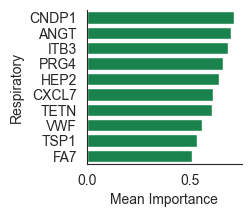

In [32]:
sns.set_style("white")

fig, ax = plt.subplots()

sns.barplot(
    data=feature_importance_results.reset_index().head(10),
    x="Mean Importance",
    y="feature",
    ax=ax,
    color=color,
)

ax.set_ylabel("Respiratory")
sns.despine()
fig.set_size_inches(
    (2, 2)
)

In [33]:
feature_importance_results["Panel"] = "Coag"

In [34]:
feature_importance_results.to_csv(
    "coag_importance.tsv",
    sep="\t",
    index=False
)

In [35]:
from joblib import dump


with open("models/coag_protein_model.pkl", "wb") as f:

    dump(protein_clf, f)

with open("models/coag_protein_scaler.pkl", "wb") as f:

    dump(protein_scaler, f)
